[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ichristov/viscoelastic-startup/blob/main/notebooks/christov_2010_stokes1_oldroydb.ipynb)

# LEARNING OBJECTIVE

After exploring this notebook, you will be able to regenerate, from scratch, the three correct representations of the solution of Stokes' first problem for an Oldroyd-B fluid collected by [Christov (2010)](https://arxiv.org/abs/1009.4416) (Fourier sine transform; Laplace transform with the Bromwich integral; Laplace transform with quotient splitting). Furthermore, you will be able to show that they agree with each other and with the finite-difference scheme of that paper, reproduce its Fig. 2, and see an erroneous solution fail. (A companion notebook does the same for the second-grade fluid.)

Where the second-grade companion has a start-up jump felt at every $y$ at once, the Oldroyd-B fluid has a wave: the retardation time, through $\kappa = \lambda_2/\lambda_1$, decides how sharp its front is, and the three representations differ mainly in how easily they can be evaluated near it.

# PRELIMINARIES

This notebook uses [NumPy](https://numpy.org) ([Harris _et al._, 2020](https://doi.org/10.1038/s41586-020-2649-2)), [SciPy](https://scipy.org) ([Virtanen _et al._, 2020](https://doi.org/10.1038/s41592-019-0686-2)), [SymPy](https://www.sympy.org) ([Meurer _et al._, 2017](https://doi.org/10.7717/peerj-cs.103)), [Matplotlib](https://matplotlib.org) ([Hunter, 2007](https://doi.org/10.1109/MCSE.2007.55)) and [mpmath](https://mpmath.org) ([mpmath development team, 2023](https://mpmath.org/)).

[run the next cell to setup Python environment customizations and load packages]

In [1]:
# interactive plots setup
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *

# plotting customizations
from matplotlib import colormaps, animation, rc
from matplotlib import pyplot as plt
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25}
plt.rcParams.update(params)
%matplotlib inline

# for animations
from IPython.display import HTML

# numerics
import numpy as np
from scipy.integrate import quad
from scipy.special import erfc
from scipy.linalg import solve_banded
import mpmath as mp
import os

# for Colab only: to save plots as files and download them
#from google.colab import files

## Credit

Initial version of this notebook written by [Ivan C. Christov](https://christov.tmnt-lab.org), Purdue University.

Reproducing results of I. C. Christov.

# THE PROBLEM

The initial-boundary-value problem (IBVP), Eq. (17) of Christov (2010), for the velocity $u(y,t)$ of an Oldroyd-B fluid above a plate suddenly moved with velocity $U_0$:
\begin{align*}
    \frac{\partial u}{\partial t} + \lambda_1 \frac{\partial^2 u}{\partial t^2}  &= \nu \frac{\partial^2 u}{\partial y^2} +  \nu\lambda_2\frac{\partial^3 u}{\partial y \partial t\partial y}, & (y,t)\in (0,\infty)\times(0, \infty),\\
    u(0,t) &= U_0H(t), \qquad u \to 0 \;\;\text{as}\;\; y\to\infty, & t>0,\\
    u(y,0) &= 0,\qquad \frac{\partial u}{\partial t}(y,0) = 0, & y >0,
\end{align*}
(correcting the misprints in the published Eqs. (12) and (17a), which read $\varrho_0\,\frac{\partial u}{\partial y}$ and $\frac{\partial u^2}{\partial t^2}$ for $\varrho_0\,\frac{\partial u}{\partial t}$ and $\frac{\partial^2 u}{\partial t^2}$), where $H(t)$ is the [Heaviside step function](https://en.wikipedia.org/wiki/Heaviside_step_function), $\nu$ is the kinematic viscosity, and $\lambda_1$, $\lambda_2$ are the relaxation and retardation times. With the dimensionless variables of Sect. 3.2 of the paper,
$$
    \tilde t = \frac{t}{\lambda_1},\qquad \tilde y = \frac{y}{\sqrt{\nu\lambda_1}},\qquad \kappa = \frac{\lambda_2}{\lambda_1},
$$
the only parameter is $\kappa$; below, $\nu = \lambda_1 = U_0 = 1$. Fig. 2 of the paper uses $\kappa = 0.2$ and $\tilde t = 1$, $7$.

For an Oldroyd-B fluid the equation of motion is a damped wave equation with retardation. The inertia of relaxation, $\lambda_1\frac{\partial^2u}{\partial t^2}$, set against $\nu\frac{\partial^2u}{\partial y^2}$, carries an elastic wave of speed $\sqrt{\nu/\lambda_1}$, which is $\tilde y = \tilde t$ in the variables above, while the mixed term $\nu\lambda_2\frac{\partial^3u}{\partial y^2\partial t}$ smooths its front over a distance that grows with $\kappa$. The two limits are the extremes: as $\kappa\to0$ (Maxwell fluid) the front becomes sharp, while $\kappa = 1$ removes the wave altogether and leaves the Newtonian $\mathrm{erfc}[\tilde y/(2\sqrt{\tilde t})]$. At $\kappa = 0.2$, the value used in Fig. 2 below, the front at $\tilde t = 1$ is the steep drop through $\tilde y \approx 1$; at $\kappa = 0.02$ it is steeper still, and by $\tilde t = 7$ it has passed beyond the plotted range.

# THE ERRONEOUS SOLUTION

> &#x26A0;&#xFE0F; **ERRONEOUS SOLUTION, reproduced as printed** in Eq. (19) of Fetecau & Fetecau (2003) ([doi:10.1016/S0020-7462(02)00117-8](https://doi.org/10.1016/S0020-7462%2802%2900117-8)), p. 1541, for $\lambda > \lambda_r$; Christov (2010) lists it among the erroneous solutions (Sect. 2.2). Their subsidiary equation, Eq. (12), lacks the term from $\frac{\partial}{\partial t}H(t) = \delta(t)$. It is shown below to be wrong.

In their notation ($\lambda = \lambda_1$, $\lambda_r = \lambda_2$, $\alpha = \nu\lambda_r$, $V = U_0$),
\begin{align*}
    v(y,t) = V &- \frac{2V}{\pi}\int_0^a \frac{r_1\exp(r_2 t) - r_2\exp(r_1 t)}{r_1 - r_2}\,\frac{\sin(y\xi)}{\xi}\,\mathrm{d}\xi\\
    &- \frac{2V}{\pi}\exp\left(-\frac{t}{2\lambda}\right)\int_a^b \exp\left(-\frac{\nu\lambda_r\xi^2}{2\lambda}t\right)\left[\cos\left(\frac{\beta t}{2\lambda}\right) + \frac{1+\nu\lambda_r\xi^2}{\beta}\sin\left(\frac{\beta t}{2\lambda}\right)\right]\frac{\sin(y\xi)}{\xi}\,\mathrm{d}\xi\\
    &- \frac{2V}{\pi}\int_b^\infty \frac{r_1\exp(r_2 t) - r_2\exp(r_1 t)}{r_1 - r_2}\,\frac{\sin(y\xi)}{\xi}\,\mathrm{d}\xi,
\end{align*}
with (their p. 1541)
\begin{align*}
    r_{1,2} &= \frac{-(1+\alpha\xi^2) \pm \sqrt{(1+\alpha\xi^2)^2 - 4\nu\lambda\xi^2}}{2\lambda},\\
    \beta &= \sqrt{4\nu\lambda\xi^2 - (1+\alpha\xi^2)^2},\\
    a &= \frac{1}{\sqrt{\nu}\left(\sqrt{\lambda} + \sqrt{\lambda-\lambda_r}\right)},\\
    b &= \frac{1}{\sqrt{\nu}\left(\sqrt{\lambda} - \sqrt{\lambda-\lambda_r}\right)}.
\end{align*}

In [2]:
# WRONG, as printed: Eq. (19) of Fetecau & Fetecau (2003), lambda > lambda_r
def ff_bracket(xi, t, nu, lam, lam_r):
    """Integrand of Eq. (19) of Fetecau & Fetecau (2003) without sin(y xi): r-form or oscillatory form, divided by xi."""
    alpha = nu*lam_r
    D = (1 + alpha*xi**2)**2 - 4*nu*lam*xi**2
    if D > 0:
        r1 = (-(1 + alpha*xi**2) + np.sqrt(D))/(2*lam)
        r2 = (-(1 + alpha*xi**2) - np.sqrt(D))/(2*lam)
        return (r1*np.exp(r2*t) - r2*np.exp(r1*t))/(r1 - r2)/xi
    if abs(D) < 1e-14:
        # limit beta -> 0 (at the breakpoints a, b)
        return np.exp(-(1 + alpha*xi**2)*t/(2*lam))*(1 + (1 + alpha*xi**2)*t/(2*lam))/xi
    beta = np.sqrt(-D)
    return (np.exp(-t/(2*lam))*np.exp(-nu*lam_r*xi**2*t/(2*lam))
            *(np.cos(beta*t/(2*lam)) + (1 + nu*lam_r*xi**2)/beta*np.sin(beta*t/(2*lam)))/xi)

def wrong_fetecau_fetecau_19(y, t, kappa, nu=1.0, lam=1.0):
    """Erroneous solution, as printed: Eq. (19) of Fetecau & Fetecau (2003), V = 1, lambda_r = kappa*lambda < lambda."""
    if y == 0:
        # the formula gives 1 at y = 0 exactly, but its limit as y -> 0+ is 1 - exp(-t/lambda_2):
        # Eq. (19) of Fetecau & Fetecau is discontinuous at the wall
        return 1.0
    lam_r = kappa*lam
    a = 1/(np.sqrt(nu)*(np.sqrt(lam) + np.sqrt(lam - lam_r)))
    b = 1/(np.sqrt(nu)*(np.sqrt(lam) - np.sqrt(lam - lam_r)))
    total = quad(lambda xi: ff_bracket(xi, t, nu, lam, lam_r)*np.sin(y*xi), 0, a, limit=200)[0]
    total = total + quad(lambda xi: ff_bracket(xi, t, nu, lam, lam_r)*np.sin(y*xi), a, b, limit=200)[0]
    # the tail decays like sin(y xi)/xi: Fourier-weighted quadrature
    total = total + quad(ff_bracket, b, np.inf, args=(t, nu, lam, lam_r), weight='sin', wvar=y, limlst=100)[0]
    return 1 - 2/np.pi*total

> &#x26A0;&#xFE0F; **END OF THE ERRONEOUS SOLUTION.** The cells below are correct.

# THE CORRECT SOLUTION

The Fourier sine transform $w(\xi,t) = \int_0^\infty u\sin(\xi y)\,\mathrm{d}y$ of the IBVP, with $u(0,t) = H(t)$ (so that $\frac{\partial}{\partial t}u(0,t) = \delta(t)$, the [Dirac delta](https://en.wikipedia.org/wiki/Dirac_delta_function)), followed by the [Laplace transform](https://en.wikipedia.org/wiki/Laplace_transform) in $t$, gives (with $\nu=\lambda_1=1$, $\lambda_2 = \kappa$)
$$
    \bar{w}(\xi,p) = \frac{\xi(1+\kappa p)}{p\left[p^2 + (1+\kappa\xi^2)p + \xi^2\right]}.
$$
The next cell derives it with SymPy, together with the transform of the wrong subsidiary equation (Eq. (12) of Fetecau & Fetecau (2003), without the $\delta(t)$ term); they should differ by the factor $1+\kappa p$.

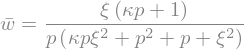

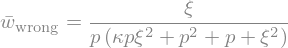

In [3]:
# Fourier-Laplace transform of Eq. (17) of Christov (2010) and of Eq. (12) of Fetecau & Fetecau (2003)
t = sp.Symbol('t', real=True)   # not positive=True, otherwise SymPy sets DiracDelta(t) = 0
p, xi, kappa = sp.symbols('p xi kappa', positive=True)
w = sp.Function('w')
W, w0, w1 = sp.symbols(r'\bar{w} w_0 w_1')

def laplace(expr):
    """Laplace transform in t, with W, w(0), w'(0) as symbols."""
    L = sp.laplace_transform(expr, t, p, noconds=True)
    L = L.subs(sp.LaplaceTransform(w(t), t, p), W)
    L = L.subs(sp.Subs(sp.Derivative(w(t), t), t, 0), w1).subs(w(0), w0)
    return sp.expand(L)

# the Fourier sine transform of d^2u/dy^2 is -xi^2 w + xi u(0,t), with u(0,t) = H(t)
lhs = w(t).diff(t) + w(t).diff(t, 2)
viscous_correct = (-xi**2*w(t) + xi*sp.Heaviside(t)) + kappa*sp.diff(-xi**2*w(t) + xi*sp.Heaviside(t), t)
viscous_wrong = (-xi**2*w(t) + xi*sp.Heaviside(t)) + kappa*sp.diff(-xi**2*w(t), t)
W_correct = sp.solve(laplace(lhs - viscous_correct).subs({w0: 0, w1: 0}), W)[0]
W_wrong = sp.solve(laplace(lhs - viscous_wrong).subs({w0: 0, w1: 0}), W)[0]
display(sp.Eq(W, sp.factor(W_correct)))
display(sp.Eq(sp.Symbol(r'\bar{w}_\mathrm{wrong}'), sp.factor(W_wrong)))

**Representation 1** ([C. I. Christov & P. M. Jordan, 2009](https://doi.org/10.1063/1.3126503)), by the Fourier sine and Laplace transforms, Eq. (18) of Christov (2010), for $\kappa < 1$:
\begin{align*}
    u(y,t) = U_0 H(t)\Bigg\{1 - \frac{2}{\pi}\Bigg[&\int_{0}^{\xi_{1}^{\bullet}}\bar{\mathcal{U}}_{+}(\xi,t)\sin\left(\tfrac{\xi y}{\sqrt{\nu\lambda_1}}\right)\mathrm{d}\xi\\
    &+ \int_{\xi_{1}^{\bullet}}^{\xi_{2}^{\bullet}}\bar{\mathcal{U}}_{-}(\xi,t)\sin\left(\tfrac{\xi y}{\sqrt{\nu\lambda_1}}\right)\mathrm{d}\xi\\
    &+ \int_{\xi_{2}^{\bullet}}^{\infty}\bar{\mathcal{U}}_{+}(\xi,t)\sin\left(\tfrac{\xi y}{\sqrt{\nu\lambda_1}}\right)\mathrm{d}\xi\Bigg]\Bigg\},
\end{align*}
(and $\mathrm{erfc}[y/(2\sqrt{\nu t})]$ for $\kappa = 1$), where, for $f(\xi)\gtrless 0$,
\begin{align*}
    \bar{\mathcal{U}}_+(\xi,t)&=\frac{\exp[-g(\xi)t/\lambda_1]\left\{\sqrt{f(\xi)}\cosh[t/\lambda_1\sqrt{f(\xi)}]+g(\xi)\sinh[t/\lambda_1\sqrt{f(\xi)}]\right\}}{\xi\sqrt{f(\xi)}}\\
    &\quad -\frac{\kappa \xi \exp[-g(\xi)t/\lambda_1]\sinh[t/\lambda_1\sqrt{f(\xi)}]}{\sqrt{f(\xi)}},\\
    \bar{\mathcal{U}}_-(\xi,t)&=\frac{\exp[-g(\xi)t/\lambda_1]\left\{\sqrt{|f(\xi)|}\cos[t/\lambda_1\sqrt{|f(\xi)|}]+g(\xi)\sin[t/\lambda_1\sqrt{|f(\xi)|}]\right\}}{ \xi\sqrt{|f(\xi)|}}\\
    &\quad -\frac{\kappa \xi \exp[-g(\xi)t/\lambda_1]\sin[t/\lambda_1\sqrt{|f(\xi)|}]}{\sqrt{|f(\xi)|}},
\end{align*}
and
\begin{align*}
    \xi_{1,2}^{\bullet} &= \kappa^{-1}\sqrt{2-\kappa\mp 2\sqrt{1-\kappa}},\\
    f(\xi) &= \tfrac{1}{4}\left[\kappa^2\xi^4 - 2(2-\kappa)\xi^2+1\right],\\
    g(\xi) &= \tfrac{1}{2}(1+\kappa \xi^2).
\end{align*}

In [4]:
# Eq. (18) of Christov (2010): Fourier sine transform representation (nu = lambda_1 = U0 = 1)
def U_bar(xi, t, kappa):
    """U-bar_+ or U-bar_- of Eq. (18) of Christov (2010), according to the sign of f(xi)."""
    f = 0.25*(kappa**2*xi**4 - 2*(2 - kappa)*xi**2 + 1)
    g = 0.5*(1 + kappa*xi**2)
    if abs(f) < 1e-14:
        # limit f -> 0 (at the breakpoints xi_1, xi_2)
        return np.exp(-g*t)*((1 + g*t)/xi - kappa*xi*t)
    if f > 0:
        r = np.sqrt(f)
        # exp(-g t) cosh(r t) and exp(-g t) sinh(r t), written so that they do not overflow
        ec = 0.5*(np.exp((r - g)*t) + np.exp(-(r + g)*t))
        es = 0.5*(np.exp((r - g)*t) - np.exp(-(r + g)*t))
        return (r*ec + g*es)/(xi*r) - kappa*xi*es/r
    r = np.sqrt(-f)
    e = np.exp(-g*t)
    return e*(r*np.cos(t*r) + g*np.sin(t*r))/(xi*r) - kappa*xi*e*np.sin(t*r)/r

def unsteadyv(y, t, kappa):
    """Correct solution, Eq. (18) of Christov (2010), kappa < 1, at one point y > 0."""
    if y == 0:
        return 1.0   # sin(0) = 0, so the formula gives the plate velocity exactly
    xi1 = np.sqrt(2 - kappa - 2*np.sqrt(1 - kappa))/kappa
    xi2 = np.sqrt(2 - kappa + 2*np.sqrt(1 - kappa))/kappa
    total = quad(lambda xi: U_bar(xi, t, kappa)*np.sin(xi*y), 0, xi1, limit=200)[0]
    total = total + quad(lambda xi: U_bar(xi, t, kappa)*np.sin(xi*y), xi1, xi2, limit=200)[0]
    total = total + quad(U_bar, xi2, np.inf, args=(t, kappa), weight='sin', wvar=y, limlst=100)[0]
    return 1 - 2/np.pi*total

**Representation 2** ([Tanner, 1962](https://doi.org/10.1007/BF01595580)), by the Laplace transform and the Bromwich integral, Eq. (19) of Christov (2010):
\begin{align*}
    u(y,t) = U_0H(t)\Bigg(\frac{1}{2} + & \frac{1}{\pi} \int_0^\infty \exp\left\{-\frac{y}{\sqrt{\nu\lambda_1}}\sqrt{\frac{\eta}{2}}\mathcal{M}(\eta)\big[\cos\theta(\eta) - \sin\theta(\eta) \big]\right\}\\
    &\times \sin\left\{\frac{t}{\lambda_1} \eta - \frac{y}{\sqrt{\nu\lambda_1}}\sqrt{\frac{\eta}{2}}\mathcal{M}(\eta) \big[\cos\theta(\eta) + \sin\theta(\eta) \big] \right\}\frac{\mathrm{d}\eta}{\eta}\Bigg),
\end{align*}
$$
    \mathcal{M}(\eta) = \sqrt[4]{\frac{1 + \eta^2}{1 + \kappa^2\eta^2}},\qquad \theta(\eta) = \tfrac{1}{2}\left[ \tan^{-1} \eta - \tan^{-1} (\kappa \eta)\right].
$$
The integrand oscillates with period $2\pi/\tilde t$ in $\eta$ and decays like $\exp(-c\sqrt{\eta})$, so the integral is summed over one period at a time.

In [5]:
# Eq. (19) of Christov (2010): Tanner's representation (nu = lambda_1 = U0 = 1)
def tanner_integrand(eta, y, t, kappa):
    """Integrand of Eq. (19) of Christov (2010)."""
    M = ((1 + eta**2)/(1 + kappa**2*eta**2))**0.25
    theta = 0.5*(np.arctan(eta) - np.arctan(kappa*eta))
    amplitude = np.exp(-y*np.sqrt(eta/2)*M*(np.cos(theta) - np.sin(theta)))
    phase = t*eta - y*np.sqrt(eta/2)*M*(np.cos(theta) + np.sin(theta))
    return amplitude*np.sin(phase)/eta

def tanner_19(y, t, kappa, eta_max=2e4):
    """Eq. (19) of Christov (2010) (Tanner, 1962), at one point y > 0."""
    if y == 0:
        return 1.0   # sin(0) = 0, so the formula gives the plate velocity exactly
    # geometric pieces near eta = 0, then one period 2 pi/t at a time
    edges = np.concatenate([[0.0], np.geomspace(1e-6, 1, 20)[1:], np.arange(1 + 2*np.pi/t, eta_max, 2*np.pi/t)])
    total = 0.0
    for i in range(len(edges) - 1):
        total = total + quad(tanner_integrand, edges[i], edges[i+1], args=(y, t, kappa), limit=100)[0]
    return 0.5 + total/np.pi

**Representation 3** ([Morrison, 1956](https://doi.org/10.1090/qam/78848)), by the Laplace transform and a splitting of the quotient, Eq. (20) of Christov (2010), for $\kappa\le1$, with $J_p$ the [Bessel function](https://en.wikipedia.org/wiki/Bessel_function) of order $p$:
\begin{align*}
    u(y,t) &= U_0H(t)\,\mathrm{e}^{(1-\kappa)\tilde t/\kappa}\Bigg(\mathrm{erfc}\left[\frac{y}{2\sqrt{\nu t\kappa}}\right] - \frac{1-\kappa}{\kappa}\int_0^{\tilde t} \mathcal{K}(\zeta)\,\mathrm{erfc}\left[\frac{y}{2\sqrt{\nu\lambda_1\zeta\kappa}}\right]\mathrm{d}\zeta\Bigg),\\
    \mathcal{K}(\zeta) &= \left\{J_0\left[\mathcal{A}(\zeta)\right] + \frac{\sqrt{\zeta}}{\sqrt{1-\kappa}\sqrt{\tilde t - \zeta}}J_1\left[\mathcal{A}(\zeta)\right]\right\}\mathrm{e}^{-(2-\kappa)(\tilde t - \zeta)/\kappa},\\
    \mathcal{A}(\zeta) &= \frac{2\sqrt{1-\kappa}}{\kappa}\sqrt{\zeta\left(\tilde t - \zeta\right)},\qquad \tilde t = \frac{t}{\lambda_1}.
\end{align*}
The kernel $\mathcal{K}$ and the Bessel argument $\mathcal{A}$ are named here to keep the display narrow; Eq. (20) of Christov (2010) writes them out. Its prefactor $\mathrm{e}^{(1-\kappa)\tilde t/\kappa}$ is about $10^{12}$ at $\tilde t = 7$, so the bracket must cancel to twelve digits; in double precision it cannot, and Eq. (20) is evaluated in 40-digit arithmetic with mpmath.

In [6]:
# Eq. (20) of Christov (2010): Morrison's representation (nu = lambda_1 = U0 = 1), in 40-digit arithmetic
def morrison_integrand(z, y, t, kappa):
    """Integrand of Eq. (20) of Christov (2010), in mpmath arithmetic."""
    c = 2*mp.sqrt(1 - kappa)/kappa
    bessels = (mp.besselj(0, c*mp.sqrt(z*(t - z)))
               + mp.sqrt(z)/(mp.sqrt(1 - kappa)*mp.sqrt(t - z))*mp.besselj(1, c*mp.sqrt(z*(t - z))))
    return bessels*mp.exp(-(2 - kappa)/kappa*(t - z))*mp.erfc(y/(2*mp.sqrt(z*kappa)))

def morrison_20(y, t, kappa):
    """Eq. (20) of Christov (2010) (Morrison, 1956), kappa <= 1, at one point y > 0."""
    # 40 digits here only, so that the rest of the notebook keeps mpmath's default precision
    with mp.workdps(40):
        y = mp.mpf(y)
        t = mp.mpf(t)
        kappa = mp.mpf(kappa)
        integral = mp.quad(lambda z: morrison_integrand(z, y, t, kappa), [0, t/2, t])
        return float(mp.exp((1 - kappa)/kappa*t)*(mp.erfc(y/(2*mp.sqrt(t*kappa))) - (1 - kappa)/kappa*integral))

def profile(func, y, t, kappa):
    """Evaluate a point-wise solution func(y, t, kappa) on an array of y > 0."""
    u = np.zeros_like(y)
    for j in range(len(y)):
        u[j] = func(y[j], t, kappa)
    return u

One Laplace-domain solution, three inversions: all three representations invert the $\bar{u}(y,p)$ of the next section, and all three are worth having, because each is the convenient one somewhere else. Eq. (18), by the Fourier sine transform, is a proper integral once the breakpoints $\xi_{1,2}^\bullet$ are located, and it is the cheapest at moderate $\tilde t$. Tanner's Eq. (19) is an oscillatory integral whose period shrinks like $1/\tilde t$, so it must be summed one period at a time, but its integrand decays like $\exp(-c\sqrt{\eta})$ and it is the easiest to evaluate at small $\tilde t$. Morrison's Eq. (20) is a finite integral of Bessel functions, yet its prefactor $\mathrm{e}^{(1-\kappa)\tilde t/\kappa}$ is about $10^{12}$ at $\tilde t = 7$, so the bracket must cancel to twelve digits and the formula has to be evaluated in extended precision. The checks below confirm that the three agree.

# AN INDEPENDENT CHECK

Two independent checks. First, the Laplace transform in $t$ of the IBVP (Tanner, 1962) gives, with $\nu = \lambda_1 = U_0 = 1$,
$$
    \bar{u}(y,p) = \frac{1}{p}\exp\left[-y\sqrt{\frac{p(1+p)}{1+\kappa p}}\right],
$$
inverted numerically by the algorithm of [de Hoog _et al._ (1982)](https://doi.org/10.1137/0903022) in [mpmath's `invertlaplace`](https://mpmath.org/doc/current/calculus/inverselaplace.html). The next cell checks with SymPy that $\bar{u}$ solves $p(1+p)\bar{u} = (1+\kappa p)\frac{\partial^2\bar{u}}{\partial y^2}$ with $\bar{u}(0,p) = 1/p$; it should print two zeros.

In [7]:
# Laplace-domain solution of Eq. (17) of Christov (2010)
y_s = sp.Symbol('y', positive=True)
ubar_sym = sp.exp(-y_s*sp.sqrt(p*(1 + p)/(1 + kappa*p)))/p
(sp.simplify(p*(1 + p)*ubar_sym - (1 + kappa*p)*ubar_sym.diff(y_s, 2)), sp.simplify(ubar_sym.subs(y_s, 0) - 1/p))

In [8]:
# Laplace-domain solution of Eq. (17) of Christov (2010), inverted by de Hoog's algorithm
def ubar_mp(p, y, kappa):
    """Laplace-domain solution in mpmath arithmetic (nu = lambda_1 = U0 = 1)."""
    return mp.exp(-y*mp.sqrt(p*(1 + p)/(1 + kappa*p)))/p

def dehoog_inverse(y, t, kappa):
    """Laplace-domain solution inverted by mpmath's de Hoog algorithm, point by point in y."""
    u = np.zeros_like(y)
    for j in range(len(y)):
        u[j] = float(mp.invertlaplace(lambda p: ubar_mp(p, y[j], kappa), t, method='dehoog'))
    return u

Second, the finite-difference scheme of Eq. (23) of Christov (2010), for $u$ and the acceleration $w = {\partial u}/{\partial t}$,
\begin{align*}
    \delta_{t+}\mathfrak{u}_j^{n-1/2} &= \mathfrak{w}_j^n,\\
    \lambda_1\delta_{t+}\mathfrak{w}_j^{n} &= -\tfrac{1}{2}(\mathfrak{w}_j^{n+1} + \mathfrak{w}_j^{n}) + \nu \delta_{y+}\delta_{y-}\mathfrak{u}_j^{n+1/2} + \nu\lambda_2\delta_{y+}\delta_{y-}\left[\tfrac{1}{2}\left(\mathfrak{w}_j^{n+1} + \mathfrak{w}_j^n\right)\right],
\end{align*}
with $\Delta y = L/(M-1)$, $\Delta t = t_f/(K-1)$ and the boundary conditions of Eq. (24), which represent $w(0,t) = U_0\delta(t)$ by a pulse of height $U_0/(n^*\Delta t)$,
\begin{align*}
    \mathfrak{u}_0^{n-1/2} &= \begin{cases}0, &n=0,\\ U_0, &1\le n\le K-1, \end{cases}\\
    \mathfrak{w}_0^n &= \begin{cases}\tfrac{U_0}{n^*\Delta t}, &1\le n \le n^*,\\ 0, &\text{otherwise}, \end{cases}\\
    \mathfrak{u}_{M-1}^n &= \mathfrak{w}_{M-1}^n = 0.
\end{align*}
Clarifying Eq. (24) of the published paper, whose ranges read $0\le n\le n^*$ and $n^*\le n\le K-1$ (overlapping at $n = n^*$): because $\mathfrak{w}_0$ enters Eq. (23) through $\tfrac{1}{2}(\mathfrak{w}^{n+1}+\mathfrak{w}^n)$, a pulse on $1\le n\le n^*$ carries exactly $U_0$, while one starting at $n = 0$ carries $(1 - 1/(2n^*))U_0$, an error that does not vanish as the grid is refined. The paper used $M=K=5000$, $L = 20$ and $n^*=10$.

In [9]:
# Eqs. (23)-(24) of Christov (2010): finite-difference scheme for u and w = du/dt (nu = lambda_1 = U0 = 1)
def ob_fd(kappa, tf, L=20.0, M=5000, K=5000, nstar=10, first=1):
    """Scheme of Eqs. (23)-(24) of Christov (2010); the delta pulse at the wall occupies first <= n < first + nstar."""
    dy = L/(M - 1)
    dt = tf/(K - 1)
    y = np.linspace(0, L, M)
    u = np.zeros(M)   # u^{-1/2}
    w = np.zeros(M)   # w^0
    if first == 0:
        w[0] = 1/(nstar*dt)
    r = kappa/(2*dy**2)
    # tridiagonal matrix of (1/dt + 1/2) - (kappa/2) delta^2/dy^2 acting on the interior points
    ab = np.zeros((3, M-2))
    ab[0, 1:] = -r
    ab[1, :] = 1/dt + 0.5 + 2*r
    ab[2, :-1] = -r
    for n in range(K - 1):
        u = u + dt*w          # u^{n+1/2}
        u[0] = 1.0
        lap_u = (u[2:] - 2*u[1:-1] + u[:-2])/dy**2
        lap_w = (w[2:] - 2*w[1:-1] + w[:-2])/dy**2
        rhs = (1/dt - 0.5)*w[1:-1] + lap_u + 0.5*kappa*lap_w
        w_new = np.zeros(M)
        if n + 1 >= first and n + 1 < first + nstar:
            w_new[0] = 1/(nstar*dt)
        rhs[0] = rhs[0] + r*w_new[0]
        w_new[1:-1] = solve_banded((1, 1), ab, rhs)
        w = w_new
    # u at t_f = (K - 1) dt, from u^{K-3/2} and w^{K-1}
    u_final = u + 0.5*dt*w
    u_final[0] = 1.0
    return y, u_final

The next cell prints the checks:

* the limit $\kappa = 1$ (Newtonian fluid), where the Laplace-domain solution is $\mathrm{erfc}[y/(2\sqrt{t})]$ and Eq. (19) should agree with it (at the quadrature tolerance);
* at $\tilde t = 1$ and $7$: the three representations against de Hoog's inversion and against each other (about $10^{-9}$ or better); the scheme on the paper's grid with the pulse on $1\le n\le n^*$ and on $0\le n< n^*$; the error of the erroneous solution, and its value at the wall, $1-\mathrm{e}^{-\tilde t/\kappa}$ instead of 1;
* the convergence of the scheme as $M = K$ is doubled (formally $O[(\Delta t)^2 + (\Delta y)^2]$, but first order in practice, because of the $\delta$ pulse at the plate), and its sensitivity to $n^*$.

In [10]:
# Checks for Christov (2010), Oldroyd-B fluid
kappa = 0.2
print('LIMIT kappa = 1 (should be at the quadrature tolerance)')
y_limit = np.array([0.2, 0.5, 1.0])
print(f'  max|Eq. (19) - erfc| = {np.abs(profile(tanner_19, y_limit, 0.5, 1.0) - erfc(y_limit/(2*np.sqrt(0.5)))).max():.1e}')

y = np.linspace(0.05, 5, 25)
for t in [1.0, 7.0]:
    print(f'\nkappa = {kappa}, t~ = {t}, max over 0.05 <= y~ <= 5')
    u_dehoog = dehoog_inverse(y, t, kappa)
    u_18 = profile(unsteadyv, y, t, kappa)
    u_19 = profile(tanner_19, y, t, kappa)
    u_20 = profile(morrison_20, y, t, kappa)
    print(f'  Eq. (18) vs de Hoog: {np.abs(u_18 - u_dehoog).max():.1e}')
    print(f'  Eq. (19) vs de Hoog: {np.abs(u_19 - u_dehoog).max():.1e}')
    print(f'  Eq. (20) vs de Hoog: {np.abs(u_20 - u_dehoog).max():.1e}')
    assert max(np.abs(u_18 - u_dehoog).max(), np.abs(u_19 - u_dehoog).max(), np.abs(u_20 - u_dehoog).max()) < 1e-6   # a regression guard: the notebook stops here if a future edit breaks the agreement
    print(f'  max pairwise difference of Eqs. (18), (19), (20): {max(np.abs(u_18 - u_19).max(), np.abs(u_18 - u_20).max(), np.abs(u_19 - u_20).max()):.1e}')
    y_fd, u_fd = ob_fd(kappa, t)
    print(f'  scheme, M = K = 5000, n* = 10, pulse on 1 <= n <= n*: {np.abs(np.interp(y, y_fd, u_fd) - u_dehoog).max():.1e}')
    y_fd, u_fd = ob_fd(kappa, t, first=0)
    print(f'  scheme, M = K = 5000, n* = 10, pulse on 0 <= n < n*: {np.abs(np.interp(y, y_fd, u_fd) - u_dehoog).max():.1e}')
    print(f'  erroneous Eq. (19) of Fetecau & Fetecau - de Hoog: {np.abs(profile(wrong_fetecau_fetecau_19, y, t, kappa) - u_dehoog).max():.2f}')
    print(f'  at y~ = 1e-5: erroneous = {wrong_fetecau_fetecau_19(1e-5, t, kappa):.5f}, 1 - exp(-t~/kappa) = {1 - np.exp(-t/kappa):.5f}')

print('\nCONVERGENCE OF THE SCHEME (pulse on 1 <= n <= n*), t~ = 1, versus de Hoog (observed order)')
u_dehoog = dehoog_inverse(y, 1.0, kappa)
for nstar in [1, 10]:
    print(f'  n* = {nstar}')
    previous = None
    for M in [1250, 2500, 5000]:
        y_fd, u_fd = ob_fd(kappa, 1.0, M=M, K=M, nstar=nstar)
        error = np.abs(np.interp(y, y_fd, u_fd) - u_dehoog).max()
        if previous is None:
            print(f'    M = K = {M:4d}: {error:.1e}')
        else:
            print(f'    M = K = {M:4d}: {error:.1e} ({np.log2(previous/error):.2f})')
        previous = error

LIMIT kappa = 1 (should be at the quadrature tolerance)


  max|Eq. (19) - erfc| = 5.6e-14

kappa = 0.2, t~ = 1.0, max over 0.05 <= y~ <= 5


  Eq. (18) vs de Hoog: 3.3e-11
  Eq. (19) vs de Hoog: 1.6e-10
  Eq. (20) vs de Hoog: 1.1e-16
  max pairwise difference of Eqs. (18), (19), (20): 1.7e-10


  scheme, M = K = 5000, n* = 10, pulse on 1 <= n <= n*: 2.3e-04


  scheme, M = K = 5000, n* = 10, pulse on 0 <= n < n*: 6.0e-03
  erroneous Eq. (19) of Fetecau & Fetecau - de Hoog: 0.12
  at y~ = 1e-5: erroneous = 0.99326, 1 - exp(-t~/kappa) = 0.99326

kappa = 0.2, t~ = 7.0, max over 0.05 <= y~ <= 5


  Eq. (18) vs de Hoog: 1.7e-16
  Eq. (19) vs de Hoog: 1.6e-11
  Eq. (20) vs de Hoog: 1.1e-16
  max pairwise difference of Eqs. (18), (19), (20): 1.6e-11


  scheme, M = K = 5000, n* = 10, pulse on 1 <= n <= n*: 1.3e-05


  scheme, M = K = 5000, n* = 10, pulse on 0 <= n < n*: 3.9e-04
  erroneous Eq. (19) of Fetecau & Fetecau - de Hoog: 0.01
  at y~ = 1e-5: erroneous = 1.00000, 1 - exp(-t~/kappa) = 1.00000

CONVERGENCE OF THE SCHEME (pulse on 1 <= n <= n*), t~ = 1, versus de Hoog (observed order)


  n* = 1
    M = K = 1250: 1.6e-04


    M = K = 2500: 7.9e-05 (0.98)


    M = K = 5000: 4.0e-05 (0.98)
  n* = 10
    M = K = 1250: 9.0e-04


    M = K = 2500: 4.5e-04 (1.00)


    M = K = 5000: 2.3e-04 (1.00)


# THE PAPER'S FIGURE

This is Fig. 2 of Christov (2010): $\tilde u$ versus $\tilde y$ for $\kappa = 0.2$ at $\tilde t = 1$ (bottom curve) and $\tilde t = 7$ (top curve), with the Fourier sine transform solution, Eq. (18) (circles), Tanner's solution, Eq. (19) (squares), Morrison's solution, Eq. (20) (diamonds), and the numerical solution by Eq. (23) (line).

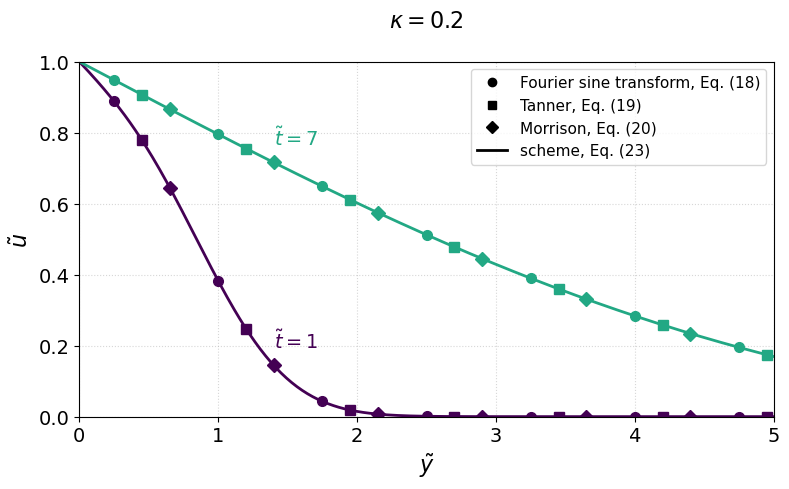

In [11]:
# Fig. 2 of Christov (2010)
kappa = 0.2
times = [1.0, 7.0]
cmap = colormaps['viridis']
y_line = np.linspace(0, 5, 400)
fig, ax = plt.subplots(figsize=(8, 5), tight_layout=True)
for k in range(len(times)):
    t = times[k]
    color = cmap(0.6*k/(len(times) - 1))
    y_fd, u_fd = ob_fd(kappa, t)
    ax.plot(y_line, np.interp(y_line, y_fd, u_fd), color=color, linewidth=2)
    y_circles = np.linspace(0.25, 4.75, 7)
    y_squares = y_circles + 0.2
    y_diamonds = y_circles + 0.4
    ax.plot(y_circles, profile(unsteadyv, y_circles, t, kappa), 'o', color=color, markersize=7)
    ax.plot(y_squares, profile(tanner_19, y_squares, t, kappa), 's', color=color, markersize=7)
    ax.plot(y_diamonds, profile(morrison_20, y_diamonds, t, kappa), 'D', color=color, markersize=7)
    ax.annotate(rf'$\tilde t = {t:g}$', xy=(1.4, np.interp(1.4, y_fd, u_fd) + 0.05), color=color, fontsize=14)

# legend entries for the methods, in black
ax.plot([], [], 'o', color='black', label='Fourier sine transform, Eq. (18)')
ax.plot([], [], 's', color='black', label='Tanner, Eq. (19)')
ax.plot([], [], 'D', color='black', label='Morrison, Eq. (20)')
ax.plot([], [], color='black', linewidth=2, label='scheme, Eq. (23)')
ax.set_xlabel(r'$\tilde y$')
ax.set_ylabel(r'$\tilde u$')
ax.set_xlim(0, 5)
ax.set_ylim(0, 1)
ax.set_title(r'$\kappa = 0.2$')
ax.grid(alpha=0.5, linestyle='dotted')
ax.legend(loc='upper right', fontsize=11)
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/christov_2010_fig2.png', dpi=200, bbox_inches='tight')

# EXPLORE IT YOURSELF

In [12]:
# Eq. (18) of Christov (2010) and Eq. (19) of Fetecau & Fetecau (2003): plot function
def plot_func(kappa, t):
    y = np.linspace(0, 5, 101)   # fine grid for the envelope
    y_arrows = np.linspace(0, 5, 16)   # about 15 arrows, one at the wall
    u = profile(unsteadyv, y, t, kappa)
    # Eq. (19) of Fetecau & Fetecau is discontinuous at the wall, so it is drawn from the first
    # grid point off it, where it is already at its limit, and not from its value at y = 0
    u_wrong = profile(wrong_fetecau_fetecau_19, y[1:], t, kappa)

    fig, ax = plt.subplots(tight_layout=True)
    ax.set_ylabel(r'$\tilde y$')
    ax.set_ylim(0, 5)
    ax.set_xlabel(r'$\tilde u$')
    ax.set_xlim(0, 1.1)
    ax.plot(u, y, color='darkblue', linewidth=4, zorder=4, label=rf'correct, $\tilde t={t:.2f}$')
    ax.quiver(0*y_arrows, y_arrows, np.interp(y_arrows, y, u), 0*y_arrows, scale=1., scale_units='xy', color='blue', zorder=3, clip_on=False)
    ax.plot(u_wrong, y[1:], color='#D55E00', linewidth=2, linestyle='dashed', zorder=4, label='wrong: Eq. (19) of Fetecau & Fetecau')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.5, linestyle='dotted')
    plt.show()

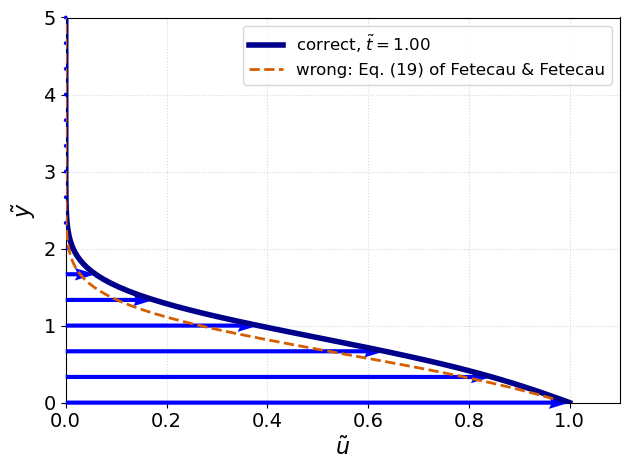

In [13]:
# Eq. (18) of Christov (2010) and Eq. (19) of Fetecau & Fetecau (2003): static plot (the interactive widget below is stripped in the GitHub preview)
plot_func(0.2, 1.0)

In [14]:
# Eq. (18) of Christov (2010) and Eq. (19) of Fetecau & Fetecau (2003): interactive plot
interact(plot_func,
         kappa=widgets.FloatSlider(value=0.2, min=0.02, max=1.0, step=0.01, description='Ratio, kappa'),
         t=widgets.FloatSlider(value=1.0, min=0.05, max=10, step=0.05, description='Time, t~'));

In [15]:
# Eq. (18) of Christov (2010) and Eq. (19) of Fetecau & Fetecau (2003): animation
kappa = 0.2
y = np.linspace(0, 5, 101)   # fine grid for the envelope
y_arrows = np.linspace(0, 5, 16)   # about 15 arrows, one at the wall
u = profile(unsteadyv, y, 0.1, kappa)

fig, ax = plt.subplots(tight_layout=True)
ax.set_ylabel(r'$\tilde y$')
ax.set_ylim(0, 5)
ax.set_xlabel(r'$\tilde u$')
ax.set_xlim(0, 1.1)
ax.grid(alpha=0.5, linestyle='dotted')
plt.close()

line, = ax.plot(u, y, color='darkblue', linewidth=4, zorder=4, label='correct')
# Eq. (19) of Fetecau & Fetecau is discontinuous at the wall, so it is drawn from the first grid point off it
line_wrong, = ax.plot(profile(wrong_fetecau_fetecau_19, y[1:], 0.1, kappa), y[1:], color='#D55E00',
                      linewidth=2, linestyle='dashed', zorder=4, label='wrong: Eq. (19) of Fetecau & Fetecau')
quiv = ax.quiver(0*y_arrows, y_arrows, np.interp(y_arrows, y, u), 0*y_arrows, scale=1., scale_units='xy', color='blue', zorder=3, clip_on=False)
ax.legend(loc='upper right')

# number of animation frames
numframes = 40
tmax = 7.0

# animation function called sequentially by `FuncAnimation' below
def animate(i):
    # the i passed is the frame counter, rescaled to get the time
    tstar = (i + 1)/numframes*tmax
    u = profile(unsteadyv, y, tstar, kappa)
    line.set_data(u, y)
    line_wrong.set_data(profile(wrong_fetecau_fetecau_19, y[1:], tstar, kappa), y[1:])
    quiv.set_UVC(np.interp(y_arrows, y, u), 0*y_arrows)
    line.set_label(rf'correct, $\tilde t={tstar:.2f}$')
    legend = ax.legend(loc='upper right')
    return (line, line_wrong, quiv, legend)

anim = animation.FuncAnimation(fig, animate, frames=numframes, interval=150, blit=True, repeat=False)

In [16]:
# this is necessary to get the animation to work on Google's Colab
rc('animation', html='jshtml')
anim

In [17]:
# To save the animation, use something like
# anim.save('christov_2010_oldroydb.mp4')

# WHAT PROBLEM DOES THE WRONG SOLUTION ACTUALLY SOLVE?

The transform of the wrong subsidiary equation is the correct one divided by $1+\kappa p$ (see the SymPy cell above), so Eq. (19) of Fetecau & Fetecau (2003) is the solution of the IBVP (17) with the plate ramped on the retardation timescale (that is, $\lambda_2$),
$$
    u(0,t) = \left(1 - \mathrm{e}^{-t/\lambda_2}\right)U_0H(t),\qquad \bar{u}_\mathrm{wrong}(y,p) = \frac{\bar{u}(y,p)}{1+\kappa p}.
$$
This identification is shown here; it is not stated in Christov (2010). It extends to this problem the ramped plate that [I. C. Christov & C. I. Christov (2010)](https://arxiv.org/abs/1003.2188) found for Stokes' first problem of a second-grade fluid. The next cell should print $1/(\kappa p + 1)$, then compare Eq. (19) of Fetecau & Fetecau (2003) with the de Hoog inversion of $\bar{u}/(1+\kappa p)$, which should agree at the quadrature tolerance.

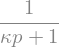

max|Eq. (19) of Fetecau & Fetecau - ramped-plate solution| = 1.4e-09


In [18]:
# Eq. (19) of Fetecau & Fetecau (2003) versus the ramped-plate solution, inverse of ubar/(1 + kappa p)
display(sp.simplify(W_wrong/W_correct))
kappa = 0.2
y = np.linspace(0.05, 5, 25)
max_difference = 0.0
for t in [1.0, 7.0]:
    u_ramp = np.zeros_like(y)
    for j in range(len(y)):
        u_ramp[j] = float(mp.invertlaplace(lambda p: ubar_mp(p, y[j], kappa)/(1 + kappa*p), t, method='dehoog'))
    max_difference = max(max_difference, np.abs(profile(wrong_fetecau_fetecau_19, y, t, kappa) - u_ramp).max())
print(f'max|Eq. (19) of Fetecau & Fetecau - ramped-plate solution| = {max_difference:.1e}')

# ON YOUR OWN

On your own:

*   Take $\kappa = 0.02$ and follow the elastic front at $\tilde y \approx \tilde t$; which representation is the hardest to evaluate there?
*   Evaluate Eq. (20) in double precision at $\tilde t = 7$ and explain the error.
*   Run `ob_fd` with $n^* = 1$, $10$ and $50$ at fixed $M = K$ and plot the error near the plate.

# REFERENCES

I. C. Christov, Stokes' first problem for some non-Newtonian fluids: Results and mistakes, _Mech. Res. Commun._ **37** (2010) 717&ndash;723. [doi:10.1016/j.mechrescom.2010.09.006](https://doi.org/10.1016/j.mechrescom.2010.09.006); [arXiv:1009.4416](https://arxiv.org/abs/1009.4416)

I. C. Christov, C. I. Christov, Comment on &ldquo;On a class of exact solutions of the equations of motion of a second grade fluid&rdquo; by C. Fetec&#259;u and J. Zierep (Acta Mech. 150, 135&ndash;138, 2001), _Acta Mech._ **215** (2010) 25&ndash;28. [doi:10.1007/s00707-010-0300-2](https://doi.org/10.1007/s00707-010-0300-2); [arXiv:1003.2188](https://arxiv.org/abs/1003.2188)

C. I. Christov, P. M. Jordan, Comment on &ldquo;Stokes' first problem for an Oldroyd-B fluid in a porous half space&rdquo; [Phys. Fluids 17, 023101 (2005)], _Phys. Fluids_ **21** (2009) 069101. [doi:10.1063/1.3126503](https://doi.org/10.1063/1.3126503)

F. R. de Hoog, J. H. Knight, A. N. Stokes, An improved method for numerical inversion of Laplace transforms, _SIAM J. Sci. Stat. Comput._ **3** (1982) 357&ndash;366. [doi:10.1137/0903022](https://doi.org/10.1137/0903022)

C. R. Harris, K. J. Millman, S. J. van der Walt, _et al._, Array programming with NumPy, _Nature_ **585** (2020) 357&ndash;362. [doi:10.1038/s41586-020-2649-2](https://doi.org/10.1038/s41586-020-2649-2)

J. D. Hunter, Matplotlib: A 2D graphics environment, _Comput. Sci. Eng._ **9** (2007) 90&ndash;95. [doi:10.1109/MCSE.2007.55](https://doi.org/10.1109/MCSE.2007.55)

A. Meurer, C. P. Smith, M. Paprocki, _et al._, SymPy: symbolic computing in Python, _PeerJ Comput. Sci._ **3** (2017) e103. [doi:10.7717/peerj-cs.103](https://doi.org/10.7717/peerj-cs.103)

J. A. Morrison, Wave propagation in rods of Voigt material and visco-elastic materials with three-parameter models, _Quart. Appl. Math._ **14** (1956) 153&ndash;169. [doi:10.1090/qam/78848](https://doi.org/10.1090/qam/78848)

The mpmath development team, _mpmath: a Python library for arbitrary-precision floating-point arithmetic_ (version 1.3.0), 2023. [mpmath.org](https://mpmath.org/)

R. I. Tanner, Note on the Rayleigh problem for a visco-elastic fluid, _Z. Angew. Math. Phys._ **13** (1962) 573&ndash;580. [doi:10.1007/BF01595580](https://doi.org/10.1007/BF01595580)

P. Virtanen, R. Gommers, T. E. Oliphant, _et al._, SciPy 1.0: fundamental algorithms for scientific computing in Python, _Nat. Methods_ **17** (2020) 261&ndash;272. [doi:10.1038/s41592-019-0686-2](https://doi.org/10.1038/s41592-019-0686-2)